# Project 22 — RAG Pipeline from Scratch
## 01 — Corpus EDA

The "dataset" of a RAG system is its **corpus**. Everything downstream — retrieval
quality, answer groundedness, cost — is decided by what the corpus looks like and
how it is cut into chunks.

This notebook answers four questions before a single vector is created:

1. What is in the corpus? (cells, types, sizes)
2. What does cleaning actually change?
3. What do the chunks look like after cell-aware chunking?
4. What are the right values for `max_words` and `sentence_overlap`?

The corpus is a 223-cell teaching notebook on retrieval-based document QnA
(`corpus/Retrival_Ext_QnA_Complete.ipynb`) — the study material the assistant
must answer from.

> All plots are written to `results/`.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

from solution import NotebookLoader, TextCleaner, NotebookChunker

os.makedirs('results', exist_ok=True)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

CORPUS_PATH = 'corpus/Retrival_Ext_QnA_Complete.ipynb'

MARKDOWN_COLOR = '#3498db'
CODE_COLOR = '#e67e22'

---
## 1. Load the corpus

A notebook is not a flat text file. It is an ordered list of **typed** cells, and
that type is the single most useful piece of metadata in the whole pipeline —
markdown explains, code demonstrates, and they must be cleaned by different rules.

In [2]:
cells_data = NotebookLoader(CORPUS_PATH).load()

print('Source file:', cells_data[0]['source'])
print('Total cells:', len(cells_data))

cell_types = {}
for cell in cells_data:
    cell_types[cell['cell_type']] = cell_types.get(cell['cell_type'], 0) + 1

print('Cell types:', cell_types)

Total cells found: 223
Source file: Retrival_Ext_QnA_Complete.ipynb
Total cells: 223
Cell types: {'markdown': 118, 'code': 105}


In [3]:
first_markdown = next(c for c in cells_data if c['cell_type'] == 'markdown')
first_code = next(c for c in cells_data if c['cell_type'] == 'code')

print('--- FIRST MARKDOWN CELL ---')
print('Cell number:', first_markdown['cell_number'],
      '| words:', first_markdown['word_count'])
print(first_markdown['text'][:400])

print()
print('--- FIRST CODE CELL ---')
print('Cell number:', first_code['cell_number'],
      '| words:', first_code['word_count'])
print(first_code['text'][:400])

--- FIRST MARKDOWN CELL ---
Cell number: 1 | words: 146
# From Extractive PDF QnA to Retrieval-Based Document QnA using Embeddings, FAISS, and BERT Reader

In the previous notebook, we already built a complete **Extractive PDF QnA system** using a BERT-style reader model.

That system covered:

- PDF reading
- Page-wise text extraction
- Text chunking with overlap
- Manual extractive QnA using `start_logits` and `end_logits`
- Answer span extraction
- 

--- FIRST CODE CELL ---
Cell number: 9 | words: 35
# Install required libraries
# PyMuPDF -> PDF reading
# transformers -> BERT-style QnA reader
# sentence-transformers -> embedding model
# faiss-cpu -> efficient vector similarity search

!pip install -q pymupdf transformers accelerate sentence-transformers faiss-cpu


### Cell type distribution

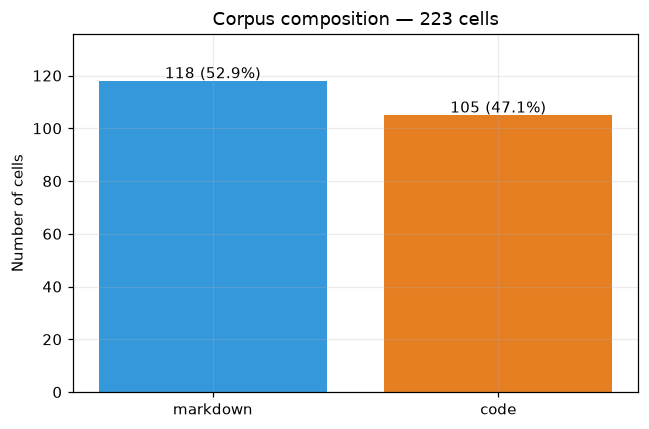

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['markdown', 'code']
counts = [cell_types.get(l, 0) for l in labels]

bars = ax.bar(labels, counts, color=[MARKDOWN_COLOR, CODE_COLOR])

for bar, count in zip(bars, counts):
    pct = 100 * count / len(cells_data)
    ax.text(bar.get_x() + bar.get_width() / 2, count + 1,
            f'{count} ({pct:.1f}%)', ha='center', fontsize=10)

ax.set_title('Corpus composition — 223 cells')
ax.set_ylabel('Number of cells')
ax.set_ylim(0, max(counts) * 1.15)

plt.tight_layout()
plt.savefig('results/cell_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading it:** the corpus is roughly half prose, half code. That balance is the
reason this pipeline needs two cleaning paths. A corpus that was 95% prose could get
away with one.

---
## 2. How long is a cell?

Cell length decides whether chunking has anything to do at all. If every cell were
under the word budget, chunking would be a no-op and each cell would become exactly
one chunk.

In [5]:
md_words = [c['word_count'] for c in cells_data if c['cell_type'] == 'markdown']
code_words = [c['word_count'] for c in cells_data if c['cell_type'] == 'code']
all_words = [c['word_count'] for c in cells_data]

def summarize(name, values):
    print(f'{name:<10} n={len(values):>4} '
          f'min={np.min(values):>4} '
          f'median={np.median(values):>7.1f} '
          f'mean={np.mean(values):>7.1f} '
          f'max={np.max(values):>5}')

summarize('markdown', md_words)
summarize('code', code_words)
summarize('all', all_words)

print()
print('Cells above the 250-word budget:',
      sum(1 for w in all_words if w > 250))
print('Cells under 20 words:',
      sum(1 for w in all_words if w < 20))

markdown   n= 118 min=  13 median=   76.0 mean=   81.5 max=  419
code       n= 105 min=   0 median=   36.0 mean=   67.9 max=  536
all        n= 223 min=   0 median=   65.0 mean=   75.1 max=  536

Cells above the 250-word budget: 6
Cells under 20 words: 22


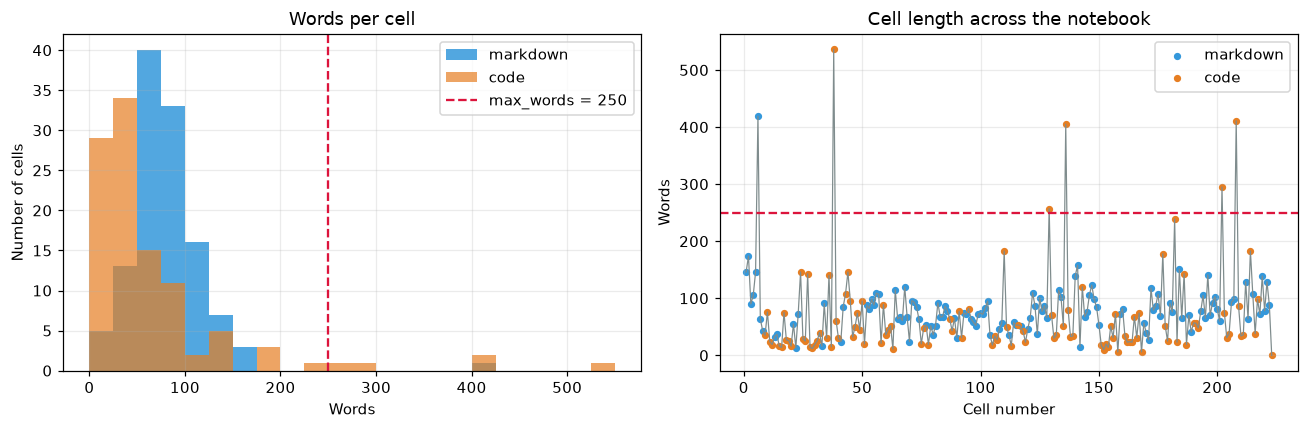

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = np.arange(0, max(all_words) + 25, 25)

axes[0].hist(md_words, bins=bins, color=MARKDOWN_COLOR, alpha=0.85, label='markdown')
axes[0].hist(code_words, bins=bins, color=CODE_COLOR, alpha=0.7, label='code')
axes[0].axvline(250, color='crimson', linestyle='--', linewidth=1.5,
                label='max_words = 250')
axes[0].set_title('Words per cell')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Number of cells')
axes[0].legend()

axes[1].plot([c['cell_number'] for c in cells_data], all_words,
             color='#7f8c8d', linewidth=0.8)
axes[1].scatter([c['cell_number'] for c in cells_data if c['cell_type'] == 'markdown'],
                md_words, s=14, color=MARKDOWN_COLOR, label='markdown')
axes[1].scatter([c['cell_number'] for c in cells_data if c['cell_type'] == 'code'],
                code_words, s=14, color=CODE_COLOR, label='code')
axes[1].axhline(250, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_title('Cell length across the notebook')
axes[1].set_xlabel('Cell number')
axes[1].set_ylabel('Words')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/cell_word_counts.png', dpi=150, bbox_inches='tight')
plt.show()

**What this tells us:** most cells are far below the 250-word budget, and only a
handful cross it. So chunking is mostly a *packing* problem, not a *splitting*
problem — and the cells that do cross the budget are the ones where the splitting
rule (lines for code, sentences for prose) actually matters.

---
## 3. What does cleaning change?

Cleaning is the stage nobody looks at and everybody blames later. Keeping the raw
text next to the cleaned text makes it auditable: any cell whose word count moves
unexpectedly can be diffed character by character.

In [7]:
cleaned_cells = TextCleaner.clean_cells(cells_data)

raw_chars = np.array([c['raw_character_count'] for c in cleaned_cells])
clean_chars = np.array([c['cleaned_character_count'] for c in cleaned_cells])
delta_chars = clean_chars - raw_chars

print('Total characters before cleaning:', int(raw_chars.sum()))
print('Total characters after  cleaning:', int(clean_chars.sum()))
print('Removed:', int(raw_chars.sum() - clean_chars.sum()),
      f'({100 * (raw_chars.sum() - clean_chars.sum()) / raw_chars.sum():.2f}%)')
print()
print('Cells changed by cleaning:', int((delta_chars != 0).sum()))
print('Cells unchanged:', int((delta_chars == 0).sum()))

Total characters before cleaning: 149049
Total characters after  cleaning: 148982
Removed: 67 (0.04%)

Cells changed by cleaning: 15
Cells unchanged: 208


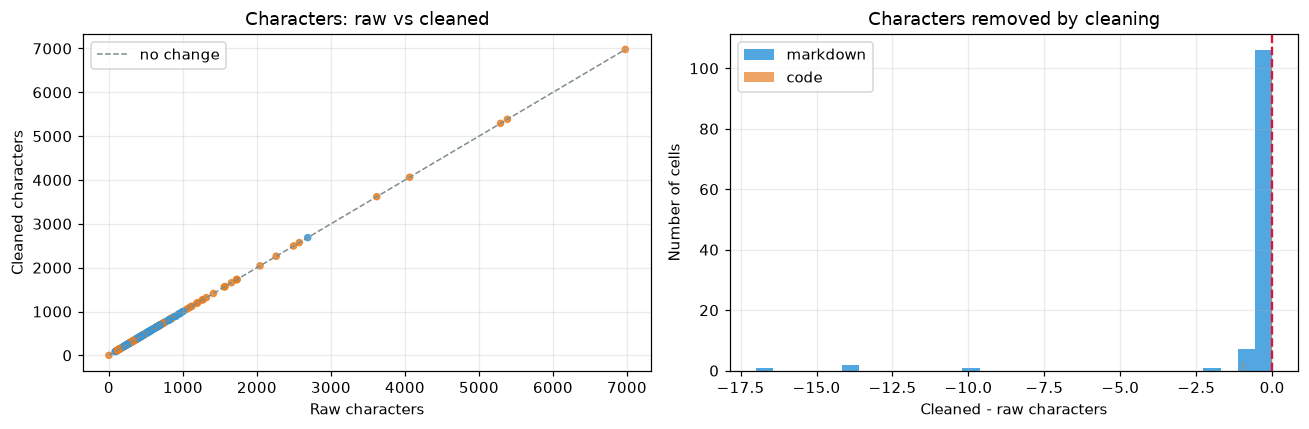

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [MARKDOWN_COLOR if c['cell_type'] == 'markdown' else CODE_COLOR
          for c in cleaned_cells]

axes[0].scatter(raw_chars, clean_chars, s=16, c=colors, alpha=0.8)
lim = max(raw_chars.max(), clean_chars.max())
axes[0].plot([0, lim], [0, lim], color='#7f8c8d', linestyle='--', linewidth=1,
             label='no change')
axes[0].set_title('Characters: raw vs cleaned')
axes[0].set_xlabel('Raw characters')
axes[0].set_ylabel('Cleaned characters')
axes[0].legend()

md_delta = [d for d, c in zip(delta_chars, cleaned_cells)
            if c['cell_type'] == 'markdown']
code_delta = [d for d, c in zip(delta_chars, cleaned_cells)
              if c['cell_type'] == 'code']

axes[1].hist(md_delta, bins=30, color=MARKDOWN_COLOR, alpha=0.85, label='markdown')
axes[1].hist(code_delta, bins=30, color=CODE_COLOR, alpha=0.7, label='code')
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_title('Characters removed by cleaning')
axes[1].set_xlabel('Cleaned - raw characters')
axes[1].set_ylabel('Number of cells')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/cleaning_impact.png', dpi=150, bbox_inches='tight')
plt.show()

### The rule cleaning must never break

Prose cleaning collapses every run of spaces. Applied to code — or to a fenced
```python block inside a markdown cell — it destroys indentation, which is exactly
the structure a code corpus needs. Verify it directly:

In [9]:
messy_markdown = '''Here is the training loop:

```python
for epoch in range(10):
    loss = train_one_epoch(   model )
```

That is    the    whole    idea.'''

cleaned_markdown = TextCleaner.clean(messy_markdown, 'markdown')

print(cleaned_markdown)
print()
print('Fenced indentation preserved:',
      '\n    loss = train_one_epoch(   model )' in cleaned_markdown)
print('Prose spacing normalised:    ',
      'That is the whole idea.' in cleaned_markdown)

Here is the training loop:

```python
for epoch in range(10):
    loss = train_one_epoch(   model )
```

That is the whole idea.

Fenced indentation preserved: True
Prose spacing normalised:     True


In [10]:
messy_code = '''def train_model(model, X, y):

    model.fit(X, y)

    if model.score(X, y) > 0.90:
        print( "good" )

    return model'''

cleaned_code = TextCleaner.clean(messy_code, 'code')

print(repr(cleaned_code[:120]))
print()
print('Indentation preserved:', '\n    model.fit(X, y)' in cleaned_code)
print('Spacing inside call untouched:', 'print( "good" )' in cleaned_code)

'def train_model(model, X, y):\n\n    model.fit(X, y)\n\n    if model.score(X, y) > 0.90:\n        print( "good" )\n\n    return'

Indentation preserved: True
Spacing inside call untouched: True


---
## 4. What do the chunks look like?

Chunks — not cells — are what gets embedded, retrieved and shown to the LLM. Two
rules shape them:

- a chunk never spans two cells (so a citation like *"Cell 54"* stays meaningful)
- consecutive chunks of the same cell share `sentence_overlap` units (so a fact
  split across a boundary survives in at least one chunk)

In [11]:
chunker = NotebookChunker(max_words=250, sentence_overlap=2)
chunks_data = chunker.chunk(cleaned_cells)

stats = NotebookChunker.describe(chunks_data)

print('Cells :', len(cells_data))
print('Chunks:', stats['total_chunks'])
print()
for key, value in stats.items():
    print(f'  {key:<16} {value}')

Cells : 223
Chunks: 230

  total_chunks     230
  min_words        6
  max_words        250
  mean_words       73.64
  median_words     65.5
  min_units        1
  max_units        24
  mean_units       3.2
  min_characters   83
  max_characters   3627
  mean_characters  651.63


markdown chunks: 120
code chunks    : 110


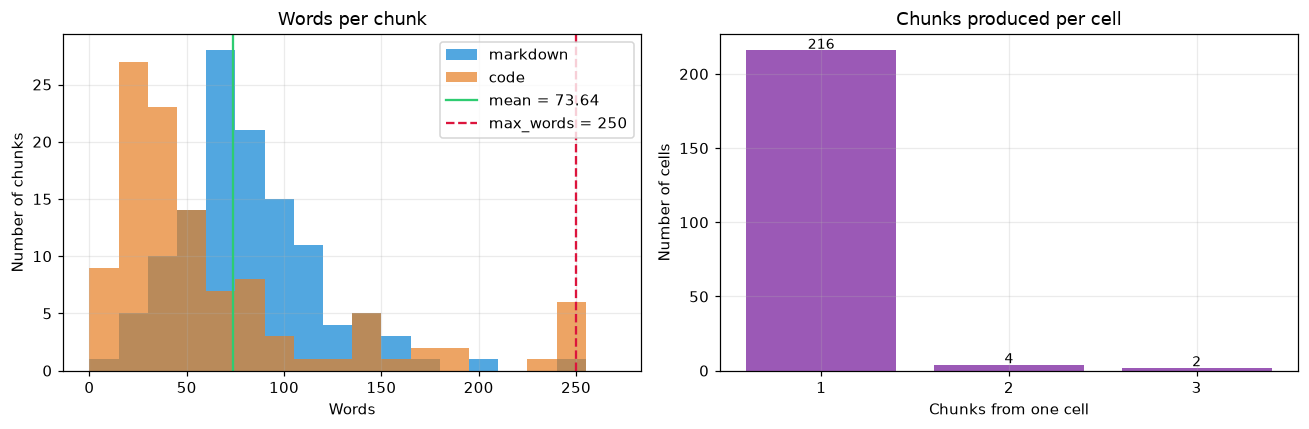

In [12]:
chunk_words = np.array([c['word_count'] for c in chunks_data])
chunk_md = [c['word_count'] for c in chunks_data if c['cell_type'] == 'markdown']
chunk_code = [c['word_count'] for c in chunks_data if c['cell_type'] == 'code']

print('markdown chunks:', len(chunk_md))
print('code chunks    :', len(chunk_code))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = np.arange(0, 275, 15)
axes[0].hist(chunk_md, bins=bins, color=MARKDOWN_COLOR, alpha=0.85, label='markdown')
axes[0].hist(chunk_code, bins=bins, color=CODE_COLOR, alpha=0.7, label='code')
axes[0].axvline(stats['mean_words'], color='#2ecc71', linewidth=1.5,
                label=f"mean = {stats['mean_words']}")
axes[0].axvline(250, color='crimson', linestyle='--', linewidth=1.5,
                label='max_words = 250')
axes[0].set_title('Words per chunk')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Number of chunks')
axes[0].legend()

chunks_per_cell = {}
for chunk in chunks_data:
    key = chunk['cell_number']
    chunks_per_cell[key] = chunks_per_cell.get(key, 0) + 1

values, counts = np.unique(list(chunks_per_cell.values()), return_counts=True)
axes[1].bar(values, counts, color='#9b59b6')
for v, c in zip(values, counts):
    axes[1].text(v, c + 1, str(c), ha='center', fontsize=9)
axes[1].set_title('Chunks produced per cell')
axes[1].set_xlabel('Chunks from one cell')
axes[1].set_ylabel('Number of cells')
axes[1].set_xticks(values)

plt.tight_layout()
plt.savefig('results/chunk_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading it:** the great majority of cells produce exactly one chunk — the corpus
is written in small, self-contained teaching cells. Only the long cells split, and
those are precisely the ones where overlap earns its keep.

In [13]:
longest = max(chunks_data, key=lambda c: c['word_count'])

print('Longest chunk')
print('  chunk_id  :', longest['chunk_id'])
print('  cell       :', longest['cell_number'], f"({longest['cell_type']})")
print('  words      :', longest['word_count'])
print('  units      :', longest['num_units'])
print()
print(longest['chunk_text'][:600])

Longest chunk
  chunk_id  : 6
  cell       : 6 (markdown)
  words      : 250
  units      : 5

Then we will use this system to expose the scalability problem.

## Stage 4: Need for Retrieval

Now the real new learning begins.
We will ask:
```text
Why should the reader process every chunk when most chunks are irrelevant?
This creates the need for a retriever.
```
## Stage 5: Text Embeddings and Semantic Search

We will convert text into vectors.
```text
Chunk → Chunk Embedding
Question → Question Embedding

Then we will compare vectors using cosine similarity.
```
## Stage 6: Manual Top-k Retrieval

We will manually retrieve the most relevant chunks using similarity scores.
This will hel


---
## 5. Choosing `max_words` and `sentence_overlap`

These two numbers are the real hyperparameters of a RAG system. They are the
chunking equivalent of the polynomial degree in Project 02 or the decision
threshold in Project 03 — sweep them, look at the tradeoff, then choose
deliberately.

**The tension:**

- small chunks → precise retrieval, but each chunk carries less context, and the
  index grows (more vectors, more embedding time, more reranker calls per query)
- large chunks → more context per hit, but the embedding of a long chunk is an
  average of several topics, which dilutes the signal the retriever matches on

In [14]:
sweep_max_words = [50, 100, 150, 200, 250, 300, 400, 600]

sweep_rows = []

for mw in sweep_max_words:
    swept = NotebookChunker(max_words=mw, sentence_overlap=2).chunk(cleaned_cells)
    s = NotebookChunker.describe(swept)
    sweep_rows.append((mw, s['total_chunks'], s['mean_words'], s['max_words']))

print(f"{'max_words':<12}{'chunks':<10}{'mean words':<14}{'largest chunk'}")
print('-' * 50)
for mw, n, mean_w, max_w in sweep_rows:
    print(f'{mw:<12}{n:<10}{mean_w:<14}{max_w}')

max_words   chunks    mean words    largest chunk
--------------------------------------------------
50          488       37.35         50
100         287       61.17         100
150         241       70.2          150
200         233       72.14         200
250         230       73.64         250
300         226       74.46         300
400         226       74.46         400
600         222       75.43         536


In [15]:
sweep_overlap = [0, 1, 2, 3, 4, 5]

overlap_rows = []
baseline_words = None

for ov in sweep_overlap:
    swept = NotebookChunker(max_words=250, sentence_overlap=ov).chunk(cleaned_cells)
    s = NotebookChunker.describe(swept)
    total_words = sum(c['word_count'] for c in swept)
    if ov == 0:
        baseline_words = total_words
    duplication = 100 * (total_words - baseline_words) / baseline_words
    overlap_rows.append((ov, s['total_chunks'], total_words, duplication))

print(f"{'overlap':<10}{'chunks':<10}{'total words':<15}{'duplication %'}")
print('-' * 48)
for ov, n, tw, dup in overlap_rows:
    print(f'{ov:<10}{n:<10}{tw:<15}{dup:>8.2f}')

overlap   chunks    total words    duplication %
------------------------------------------------
0         229       16745              0.00
1         229       16761              0.10
2         230       16938              1.15
3         231       17240              2.96
4         231       17256              3.05
5         231       17256              3.05


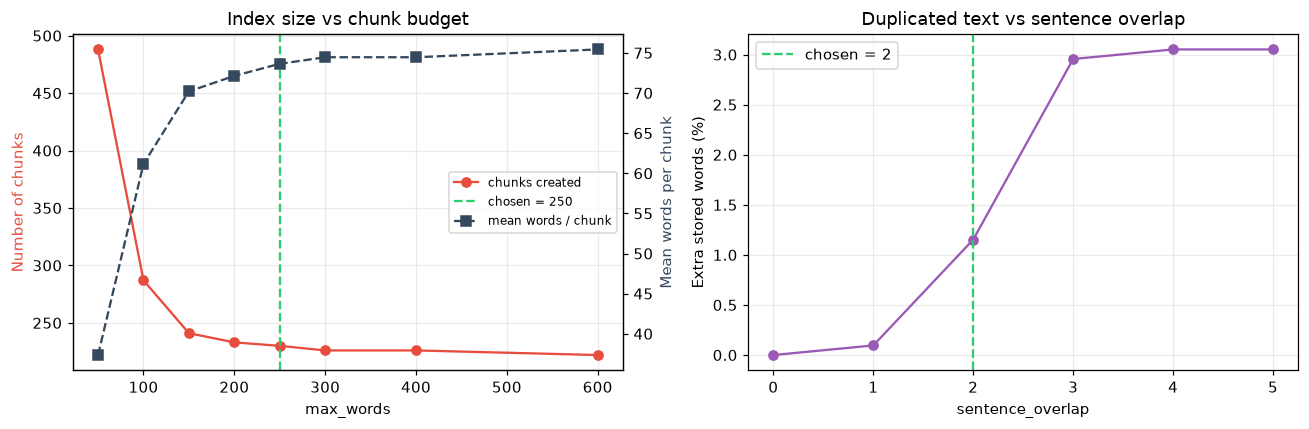

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mw_values = [r[0] for r in sweep_rows]
mw_chunks = [r[1] for r in sweep_rows]
mw_mean = [r[2] for r in sweep_rows]

ax1 = axes[0]
ax1.plot(mw_values, mw_chunks, 'o-', color='#e74c3c', label='chunks created')
ax1.axvline(250, color='#2ecc71', linestyle='--', linewidth=1.5, label='chosen = 250')
ax1.set_xlabel('max_words')
ax1.set_ylabel('Number of chunks', color='#e74c3c')
ax1.set_title('Index size vs chunk budget')

ax1b = ax1.twinx()
ax1b.plot(mw_values, mw_mean, 's--', color='#34495e', label='mean words / chunk')
ax1b.set_ylabel('Mean words per chunk', color='#34495e')
ax1b.grid(False)

lines = ax1.get_lines() + ax1b.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='center right', fontsize=8)

ov_values = [r[0] for r in overlap_rows]
ov_dup = [r[3] for r in overlap_rows]

axes[1].plot(ov_values, ov_dup, 'o-', color='#9b59b6')
axes[1].axvline(2, color='#2ecc71', linestyle='--', linewidth=1.5,
                label='chosen = 2')
axes[1].set_title('Duplicated text vs sentence overlap')
axes[1].set_xlabel('sentence_overlap')
axes[1].set_ylabel('Extra stored words (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/chunking_hyperparameter_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

**The decision.**

`max_words = 250` sits where the curve has already flattened: pushing the budget
higher barely reduces the number of chunks, because most cells are short enough to
fit anyway — you only make the few long chunks harder to retrieve precisely.
Dropping to 50 or 100 nearly doubles the index and shreds long code cells for no
retrieval benefit.

`sentence_overlap = 2` costs a small percentage of duplicated text and buys boundary
safety. Overlap only applies inside cells that split at all, which is why the cost
stays modest here.

---
## 6. What retrieval will have to work with

A last sanity check before embedding: are there chunks so short that they carry no
retrievable meaning, and does every chunk still carry its citation metadata?

In [17]:
short_chunks = [c for c in chunks_data if c['word_count'] < 20]

print('Chunks under 20 words:', len(short_chunks))
for chunk in short_chunks[:5]:
    print(f"  chunk {chunk['chunk_id']:>3} | cell {chunk['cell_number']:>3} "
          f"| {chunk['cell_type']:<8} | {chunk['word_count']:>3} words "
          f"| {chunk['chunk_text'][:60]!r}")

required_keys = ['chunk_id', 'source', 'cell_number', 'cell_type',
                 'chunk_text', 'word_count', 'preview']

print()
print('Every chunk carries full citation metadata:',
      all(all(k in c for k in required_keys) for c in chunks_data))
print('Chunk ids are sequential:',
      [c['chunk_id'] for c in chunks_data] == list(range(len(chunks_data))))

Chunks under 20 words: 22
  chunk  13 | cell  12 | code     |  19 words | '# Reproducibility helper\n\ndef set_seed(seed: int = 42):\n    '
  chunk  16 | cell  15 | code     |  16 words | '# Upload PDF file from local system\n\nuploaded = files.upload'
  chunk  17 | cell  16 | code     |  14 words | '# Open PDF using PyMuPDF\n\ndoc = fitz.open(pdf_path)\n\nprint("'
  chunk  21 | cell  20 | code     |  16 words | '# Check pages with very little or no extracted text\n\nlow_tex'
  chunk  23 | cell  22 | markdown |  13 words | 'Next, we will clean the extracted text and create overlappin'

Every chunk carries full citation metadata: True
Chunk ids are sequential: True


---
## Findings

1. **223 cells → 230 chunks.** Chunking is nearly one-to-one here because the corpus
   is written in short teaching cells. The pipeline is still needed for the handful
   of long cells — and those are the ones a naive splitter mangles.

2. **The corpus is ~53% markdown, ~47% code.** Both halves must be indexed, and they
   need different cleaning rules. Prose normalisation applied to code destroys
   indentation.

3. **Cleaning removes only a small percentage of characters** — tokenizer artefacts,
   invisible Unicode, redundant whitespace — but the characters it must *not* remove
   (Python indentation, fenced blocks) are the ones that decide whether a retrieved
   code chunk is readable.

4. **`max_words = 250`, `sentence_overlap = 2`** are on the flat part of both curves:
   a larger budget buys almost nothing, a smaller one doubles the index.

5. **Every chunk keeps `source`, `cell_number` and `cell_type`,** so any answer the
   system produces can be traced back to a specific cell of the study material.

Next: `02_implementation.ipynb` — embed these chunks with BGE-M3, index them in
Qdrant, retrieve, rerank with a cross-encoder, and generate a grounded answer.